# Raster Plot:

This notebook loads spike data from `data_path` and plots a neuron raster for 0-5000 ms.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import helpers

In [31]:
data_path = "outputs/data_custom_stim_0.05scale_7s/experiment_d"
stim_pulses_path = "outputs/data_custom_stim_0.05scale_7s/experiment_d/stim_pulses.pkl"



In [34]:
import os
import glob

import numpy as np


begin_ms = 1000
end_ms = 4000


def load_spikes_robust(path, name_prefix, begin, end):
    spike_files = sorted(glob.glob(os.path.join(path, f"{name_prefix}-*.dat")))
    if len(spike_files) == 0:
        raise FileNotFoundError(f"No files found for prefix '{name_prefix}' in {path}")

    node_ids = np.loadtxt(os.path.join(path, "population_nodeids.dat"), dtype=int)
    if node_ids.ndim == 1:
        node_ids = node_ids[None, :]

    last_node_id = node_ids[-1, -1]
    all_times = []
    all_neurons = []

    for file_path in spike_files:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                parts = stripped.split()
                if len(parts) < 2:
                    continue
                try:
                    sender = int(float(parts[0]))
                    time_ms = float(parts[1])
                except ValueError:
                    continue

                if begin <= time_ms <= end:
                    neuron_idx = abs(sender - last_node_id) + 1
                    all_times.append(time_ms)
                    all_neurons.append(neuron_idx)

    return np.array(all_times), np.array(all_neurons), spike_files


times_all, neurons_all, spike_files = load_spikes_robust(
    data_path, "spike_recorder", begin_ms, end_ms
)

if len(times_all) == 0:
    print("No spikes found in the selected interval.")
else:
    print(f"Loaded {len(times_all)} spikes from {len(spike_files)} files.")

Loaded 24937 spikes from 32 files.


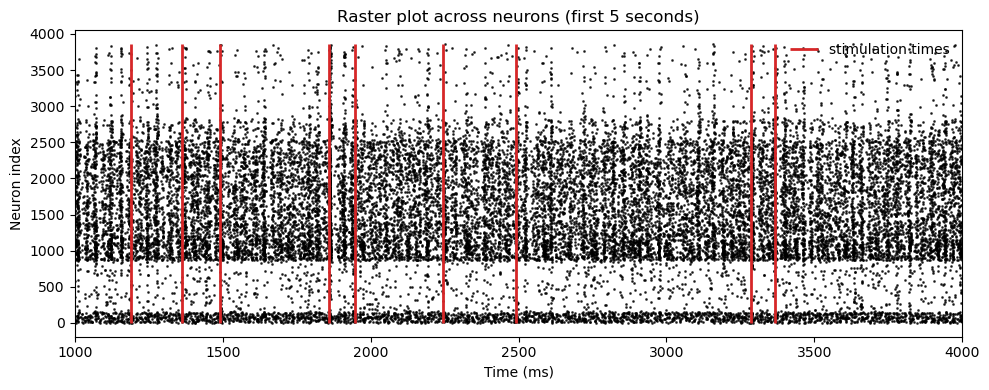

In [35]:
import os
import pickle

if len(times_all) > 0:
    plt.figure(figsize=(10, 4))
    plt.scatter(times_all, neurons_all, s=1, c="k", alpha=0.7)

    stim_times_ms = np.array([])

    if os.path.exists(stim_pulses_path):
        with open(stim_pulses_path, "rb") as f:
            stim_onset_times_by_ch = pickle.load(f)

        if isinstance(stim_onset_times_by_ch, dict):
            all_stim_times = []
            for ch_times in stim_onset_times_by_ch.values():
                all_stim_times.extend(ch_times)
            stim_times_ms = np.asarray(all_stim_times, dtype=float)
            stim_times_ms = np.unique(stim_times_ms)

        stim_times_ms = stim_times_ms[
            (stim_times_ms >= begin_ms)
            & (stim_times_ms <= end_ms)
        ]

    ymin, ymax = np.min(neurons_all), np.max(neurons_all)
    if stim_times_ms.size > 0:
        plt.vlines(
            stim_times_ms ,
            ymin,
            ymax,
            colors="tab:red",
            alpha=1,
            linewidth=2,
            label="stimulation times",
        )
        plt.legend(loc="upper right", frameon=False)

    plt.xlim(begin_ms, end_ms)
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron index")
    plt.title("Raster plot across neurons (first 5 seconds)")
    plt.tight_layout()
    plt.show()

In [25]:
stim_times_ms = np.asarray(stim_payload["times_ms"], dtype=float)

In [26]:
stim_times_ms

array([  125.,   125.,   125., ..., 59808., 59808., 59808.], shape=(6240,))